### Test acoular

In [1]:
import acoular as ac
import numpy as np

# ac.demo.acoular_demo.run()

### Microphones setup

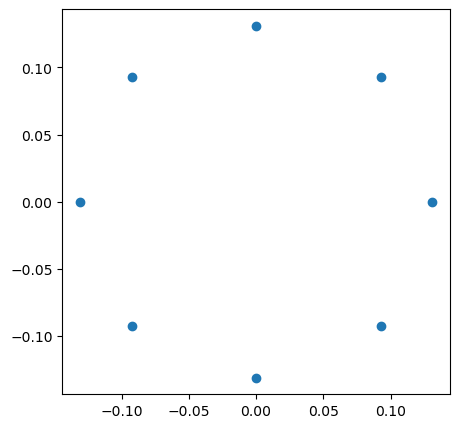

In [ ]:
from pylab import figure, plot, axis, show

r = 0.131  # microphones are set up in a regular octagon with a side equal 10cm


mg = ac.MicGeom()
mg.mpos_tot = np.array(
    [
        (
            r * np.sin(2 * np.pi * i + np.pi / 4),
            r * np.cos(2 * np.pi * i + np.pi / 4),
            0,
        )
        for i in np.linspace(0.0, 1.0, 8, False)
    ],
).T


figure(2, figsize=(5, 5))
plot(mg.mpos[0], mg.mpos[1], "o")
axis("equal")
show()

### Load sound file

In [4]:
datafile = "./output/audio.h5"

# We start with making the data from the HDF5 file available and create and instance of TimeSamples
ts = ac.TimeSamples(name=datafile)
print("Number of channels: ", ts.numchannels)
print("Number of time data samples: ", ts.numsamples)
print("Sample freq: ", ts.sample_freq)
print("Length in seconds: ", ts.numsamples / ts.sample_freq)

Number of channels:  8
Number of time data samples:  1728000
Sample freq:  96000.0
Length in seconds:  18.0


Define the evaluation grid and the steering vector.

In [5]:
# we create a RectGrid object, which provides possible source positions in a regular, two-dimensional grid with rectangular shape:
rg = ac.RectGrid(x_min=-5, x_max=5, y_min=-5, y_max=5, z=1, increment=0.5)
print("Rect size: ", rg.size)

# The sound propagation model (including the source model and transfer path) is contained in a SteeringVector object,
# which is given the focus grid and microphone arrangement to calculate the steering vector, which also contains a weighting of the transfer functions from grid points to microphone positions:
st = ac.SteeringVector(grid=rg, mics=mg)

Rect size:  441


### Plot the result of beamforming

[('audio_cache.h5', 3)]
[('audio_cache.h5', 4)]


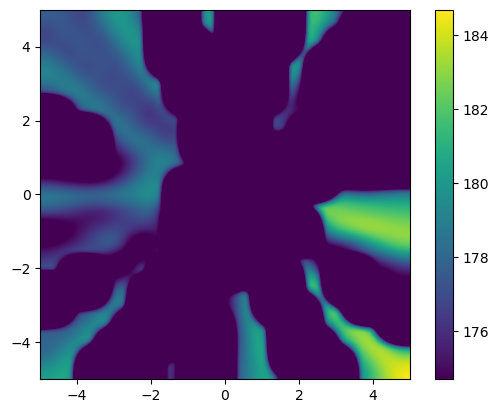

In [9]:
from pylab import figure, imshow, colorbar

# To provide the facilities to calculate the cross spectral matrix we create an instance of PowerSpectra
ps = ac.PowerSpectra(source=ts, block_size=128, window="Hanning")

# Finally, we can create the object that encapsulates the delay-and-sum algorithm. The basic beamforming algorithm is provided by objects of the type BeamformerBase
bb = ac.BeamformerBase(freq_data=ps, steer=st)

# the beamforming result mapped onto the grid is queried for a frequency of 8000 Hz and over a third-octave wide frequency band (thus the ‘3’ in the second argument).
pm = bb.synthetic(8000, 3)

# As a consequence, processing starts: the data is read from the file, the cross spectral matrix is computed and the beamforming is performed. The result (sound pressure squared) is given as an array with the same shape as the grid.
# Using the helper function L_p, this is converted to decibels.
Lm = ac.L_p(pm)

figure()  # open new figure

imshow(
    Lm.T,
    origin="lower",
    vmin=Lm.max() - 10,
    extent=rg.extend(),
    interpolation="bicubic",
)

colorbar()

### Fixed focus time domain beamforming

In [14]:
FPS = 30

# maybe only keep 270hz to test sawtooth
fi = ac.FiltFiltOctave(source=ts, band=144, fraction="Third octave")
bt = ac.BeamformerTimeSq(source=fi, steer=st, r_diag=True)
avgt = ac.Average(source=bt, naverage=int(ts.sample_freq / FPS))
cacht = ac.Cache(source=avgt)  # cache to prevent recalculation

Plot single frames

[('audio_cache.h5', 6)]


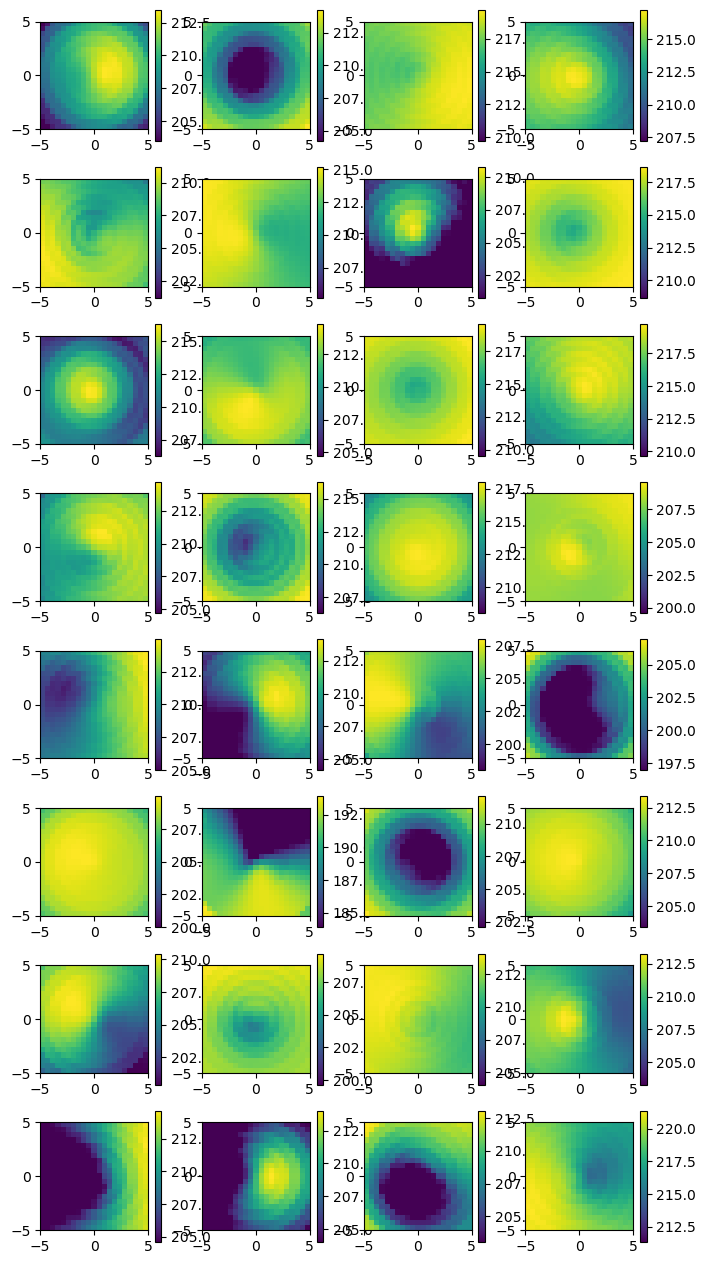

In [13]:
from pylab import (
    axis,
    colorbar,
    figure,
    imshow,
    subplot,
    tight_layout,
    transpose,
)

figure(1, (8, 16))
i = 0
for res in cacht.result(1):
    res0 = res[0].reshape(rg.shape)
    i += 1
    if i > 32:
        break

    subplot(8, 4, i)
    mx = ac.L_p(res0.max())
    imshow(
        ac.L_p(transpose(res0)),
        vmax=mx,
        vmin=mx - 10,
        interpolation="nearest",
        extent=rg.extend(),
        origin="lower",
    )
    colorbar()

Create animation from frames

[('audio_cache.h5', 7)]
Video saved as './output/frames.mp4'


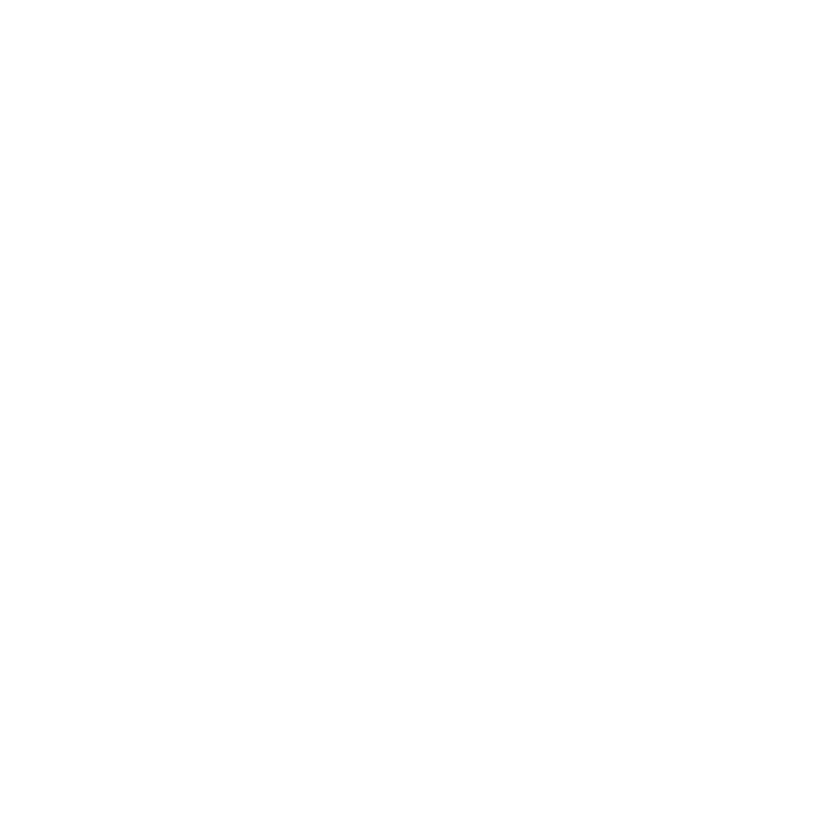

In [15]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Create figure for animation
fig, ax = plt.subplots(figsize=(8, 8))

# Remove margins and axes
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

def init():
    ax.clear()
    ax.axis("off")

# Animation function
def update(frame):
    res = np.array(frame[0]).reshape(rg.shape)
    mx = ac.L_p(res.max())
    ax.clear()  # Clear previous plot
    ax.imshow(
        ac.L_p(np.transpose(res)),
        vmax=mx,
        vmin=mx - 10,
        interpolation="nearest",
        extent=rg.extend(),
        origin="lower",
    )

# Prepare frames
frames = list(cacht.result(1))

ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init, repeat=False)

# Save as video
ani.save("./output/frames.mp4", writer="ffmpeg", fps=FPS)  # Adjust FPS as needed

print("Video saved as './output/frames.mp4'")